# 사용자 가입 분석 (Acquisition)

- 중·고등학생을 주요 타깃으로 하는 서비스의 특성상, 활성화(`Activation`)와 리텐션(`Retention`)이 양호하더라도 **진급 및 졸업에 따른 구조적인 사용자 이탈**이 불가피합니다.

- 따라서 자연 이탈로 인한 사용자 감소를 상쇄하고 지속적인 성장을 이어가기 위해서는 **안정적인 신규 사용자 획득(`Acquisition`)**이 중요한 과제라고 판단했습니다.

- 본 분석에서는 **신규 사용자의 가입 시점, 특성, 지역 및 가입 패턴 등을 다양한 관점에서 탐색**하고, 이를 바탕으로 **향후 사용자 획득 단계에서 어떤 부분에 집중할 필요가 있는지 파악하는 것**을 목표로 합니다.

## 0. 라이브러리 호출 및 환경 세팅

### 0-1. 라이브러리 호출

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

### 0-2. 시각화 공통 환경 세팅

In [5]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

### 0-3. 함수 정의

In [6]:
def plot_monthly_signups(data, title):
    data = data.sort_values('signup_month').copy()
    data['monthly_change'] = data['unique_users'].diff()

    fig, ax = plt.subplots(figsize=(16, 6))

    # 라인그래프 생성
    sns.lineplot(
        data=data,
        x='signup_month',
        y='unique_users',
        marker='o',
        linewidth=2.5,
        color='#3182bd',
        ax=ax,
    )

    # 표시된 월별 가입자 수의 중앙값
    median_users = data['unique_users'].median()
    ax.axhline(
        y=median_users,
        color='darkorange',
        linestyle='--',
        linewidth=1.5,
        label=f'중앙값: {median_users:,.0f}명',
    )
    ax.legend(loc='upper right')

    # 각 데이터 포인트에 숫자 레이블 표시
    for row in data.itertuples(index=False):
        x, y, change = (
            row.signup_month,
            row.unique_users,
            row.monthly_change,
        )
        # 중앙값 이상인 월의 가입자 수 강조
        is_above_median = y >= median_users
        ax.annotate(
            f'{int(y):,}명',
            (x, y),
            xytext=(0, 23),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            fontweight='bold' if is_above_median else 'normal',
            bbox=(
                dict(
                    boxstyle='round,pad=0.25',
                    facecolor='#FFF3CD',
                    edgecolor='darkorange',
                    linewidth=0.8,
                )
                if is_above_median else None
            ),
        )

        # 전월 대비 증감량
        if pd.isna(change):
            label, color = '비교 없음', 'gray'
        elif change > 0:
            label, color = f'+{int(change):,}명', 'red'
        elif change < 0:
            label, color = f'{int(change):,}명', 'blue'
        else:
            label, color = '0명', 'gray'

        ax.annotate(
            label,
            (x, y),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
        )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입 월', fontsize=11)
    ax.set_ylabel('가입 유저 수(명)', fontsize=11)

    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, data['unique_users'].max() * 1.25)

    fig.tight_layout()
    plt.show()

In [7]:
def plot_area_signups(data, label_col, title):
    fig, ax = plt.subplots(
        figsize=(12, max(5, len(data) * 0.4))
    )

    bars = ax.barh(
        data[label_col],
        data['가입자 수'],
        color='#3182bd',
    )

    ax.bar_label(
        bars,
        labels=[
            f'{count:,.0f}명 ({share:.2f}%)'
            for count, share in zip(data['가입자 수'], data['비중(%)'])
        ],
        padding=5,
        fontsize=9,
    )

    ax.invert_yaxis()
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입자 수(명)')
    ax.set_ylabel('')
    ax.set_xlim(0, data['가입자 수'].max() * 1.35)

    fig.tight_layout()
    plt.show()


In [8]:
def summarize_group_burst(group, window_hours=24):
    times = group['signup_date'].sort_values().reset_index(drop=True)
    window = pd.Timedelta(hours=window_hours)
    right = 0
    best_left = 0
    best_count = 0

    for left in range(len(times)):
        while right < len(times) and times.iloc[right] < times.iloc[left] + window:
            right += 1
        count = right - left
        if count > best_count:
            best_left = left
            best_count = count

    start = times.iloc[best_left]
    return {
        '가입자 수': len(times),
        '최대 구간 가입자 수': best_count,
        '가입 집중도(%)': best_count / len(times) * 100,
        '집중 구간 시작': start,
        '집중 구간 종료(미포함)': start + window,
        '그룹 최초 가입': times.iloc[0],
        '그룹 최종 가입': times.iloc[-1],
    }

In [9]:
def analyze_signup_bursts(data, entity_col, min_users, window_hours):
    # 1. 필요한 컬럼 선택 및 결측·중복 정리
    signups = (
        data[['user_id', entity_col, 'signup_date']]
        .dropna(subset=['user_id', entity_col, 'signup_date'])
        .sort_values('signup_date')
        .drop_duplicates([entity_col, 'user_id'], keep='first')
        .copy()
    )

    # 시간 변환 없이 기존 datetime 사용
    if not pd.api.types.is_datetime64_any_dtype(signups['signup_date'].dtype):
        raise TypeError('signup_date가 datetime 형식인지 확인해 주세요.')

    # 2. 최소 인원 이상인 집단만 선택
    sizes = signups.groupby(entity_col)['user_id'].nunique()
    eligible_ids = sizes[sizes >= min_users].index

    eligible_signups = signups[
        signups[entity_col].isin(eligible_ids)
    ]

    # 3. 기존 함수를 각 집단에 적용
    records = []

    for entity_id, members in eligible_signups.groupby(entity_col):
        records.append({
            entity_col: entity_id,
            **summarize_group_burst(
                members,
                window_hours=window_hours,
            ),
        })

    # 4. 결과표 생성
    columns = [
        entity_col,
        '가입자 수',
        '최대 구간 가입자 수',
        '가입 집중도(%)',
        '집중 구간 시작',
        '집중 구간 종료(미포함)',
        '그룹 최초 가입',
        '그룹 최종 가입',
    ]

    summary = (
        pd.DataFrame(records, columns=columns)
        .rename(columns={
            '그룹 최초 가입': '최초 가입',
            '그룹 최종 가입': '최종 가입',
        })
        .sort_values(
            ['가입 집중도(%)', '최대 구간 가입자 수'],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    coverage = pd.DataFrame({
        '구분': ['전체 유효 집단', '분석 대상 집단', '최소 인원 미달 집단'],
        '집단 수': [
            len(sizes),
            len(eligible_ids),
            len(sizes) - len(eligible_ids),
        ],
    })

    return summary, coverage

In [10]:
def summarize_burst_distribution(
    data,
    entity_label='학교',
    window_hours=72,
):
    labels = [
        f'{start}~{start + 10}% 미만'
        for start in range(0, 90, 10)
    ] + ['90~100%']

    count_col = f'{entity_label} 수'
    share_col = f'{entity_label} 비중(%)'

    distribution = (
        pd.cut(
            data['가입 집중도(%)'],
            bins=list(range(0, 100, 10)) + [float('inf')],
            labels=labels,
            right=False,
        )
        .value_counts(sort=False)
        .rename_axis(f'{window_hours}시간 가입 집중도 구간')
        .reset_index(name=count_col)
    )

    distribution[share_col] = (
        (distribution[count_col] / len(data) * 100).round(2)
        if len(data) else float('nan')
    )

    return distribution

### 0-4. 데이터 호출

In [11]:
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [12]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

   user_id                      signup_date  group_id  grade  school_id  \
0   854579 2023-04-29 14:58:10.258013+00:00      5384      1       5635   
1   860264 2023-04-30 13:57:44.499021+00:00      6687      1       5257   
2   860491 2023-04-30 14:12:42.390512+00:00      2842      1       2588   
3   877440 2023-05-03 14:51:51.083512+00:00      2658      1       2599   
4   949655 2023-05-07 07:22:57.503677+00:00     18574      1       4496   

       address school_type  
0      경기도 가평군           H  
1  경기도 성남시 분당구           H  
2    서울특별시 강남구           H  
3    서울특별시 강남구           H  
4      경기도 화성시           H  


In [13]:
# 데이터 규모
print(f'분석 데이터 규모 {df.shape}')
print(df['user_id'].nunique())

분석 데이터 규모 (676984, 7)
676984


## 1. 월별 가입자 추이 분석

- **분석 대상:** 전체 가입자 676,984명

- 전체 사용자의 **가입 일시를 기준으로 월별 신규 가입자 수의 추이와 변화 패턴**을 확인합니다.

In [14]:
# datetime 변환 후 YYYY-MM 포맷으로 추출
df['signup_month'] = pd.to_datetime(df['signup_date']).dt.strftime('%Y-%m')

# 연월별 유니크 가입자 수 집계
monthly_summary = df.groupby(by='signup_month')['user_id'].nunique().reset_index(name='unique_users')
# 실제 전월과 비교하도록 누락된 월도 포함하고 시간순으로 정렬
monthly_summary = (
    monthly_summary.set_index('signup_month')
    .reindex(
        pd.period_range(
            monthly_summary['signup_month'].min(),
            monthly_summary['signup_month'].max(),
            freq='M',
        ).astype(str),
        fill_value=0,
    )
    .rename_axis('signup_month')
    .reset_index()
)

print(monthly_summary.head())

  signup_month  unique_users
0      2023-03            22
1      2023-04         19030
2      2023-05        635478
3      2023-06         16732
4      2023-07          1832


findfont: Failed to find font weight bold, now using 400.


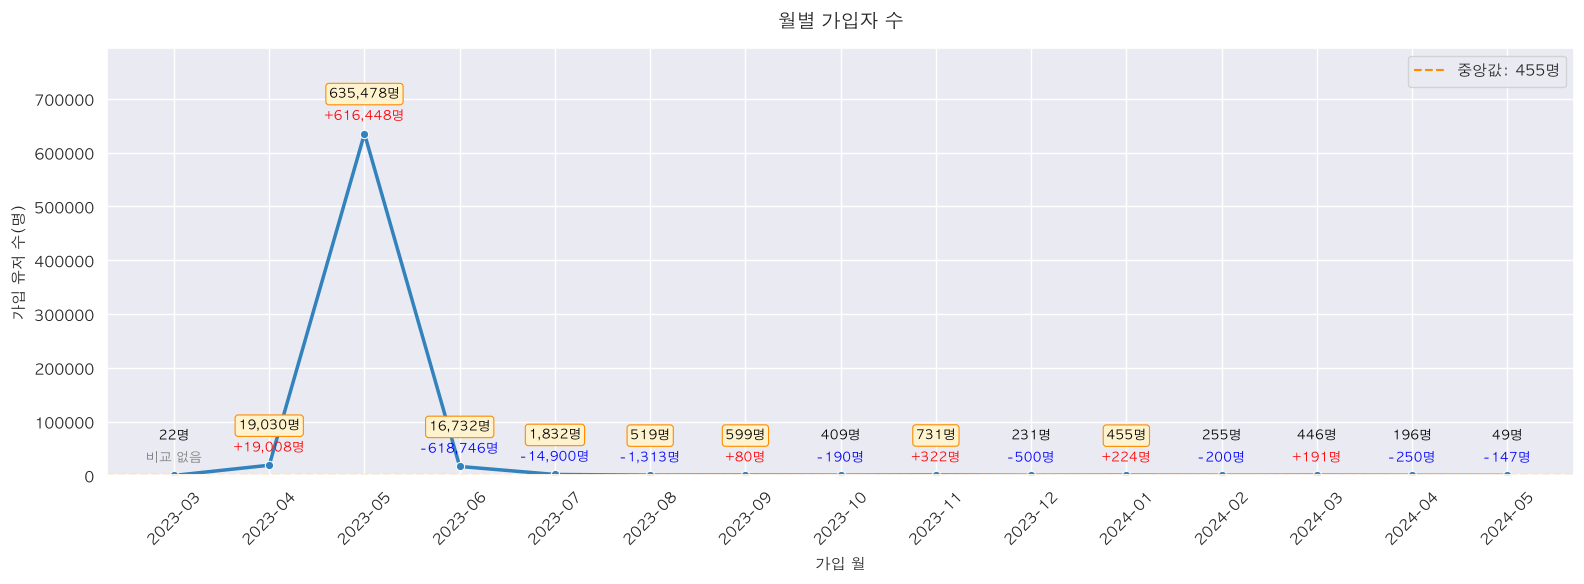

In [15]:
plot_monthly_signups(monthly_summary, '월별 가입자 수')

💡 차트 설명
- **직전 표시 월 대비:** 직전 표시 월과 비교한 가입자 수 증감
  - 🔴 **빨강:** 직전 표시 월 대비 가입자 수 증가
  - 🔵 **파랑:** 직전 표시 월 대비 가입자 수 감소
- 🟨 **노란색 박스:** 전체 기간의 월별 가입자 수 **중앙값 이상을 기록한 월**

---

- **5월 가입자 수가 매우 큰 폭으로 증가**했으나, 6월에 급격히 감소하며 증가세가 일시적인 현상에 그쳤습니다.

- 5월의 급격한 증가로 인해 **다른 월의 가입자 추이가 상대적으로 명확하게 드러나지 않아**, 5월 데이터를 제외한 후 월별 추이를 재확인을 진행합니다.

In [16]:
# 5월 제외 후 추이 재확인용 데이터
monthly_summary_ex_may = monthly_summary[
    ~monthly_summary['signup_month'].str.endswith('23-05')
].reset_index(drop=True)

print(monthly_summary_ex_may)

   signup_month  unique_users
0       2023-03            22
1       2023-04         19030
2       2023-06         16732
3       2023-07          1832
4       2023-08           519
5       2023-09           599
6       2023-10           409
7       2023-11           731
8       2023-12           231
9       2024-01           455
10      2024-02           255
11      2024-03           446
12      2024-04           196
13      2024-05            49


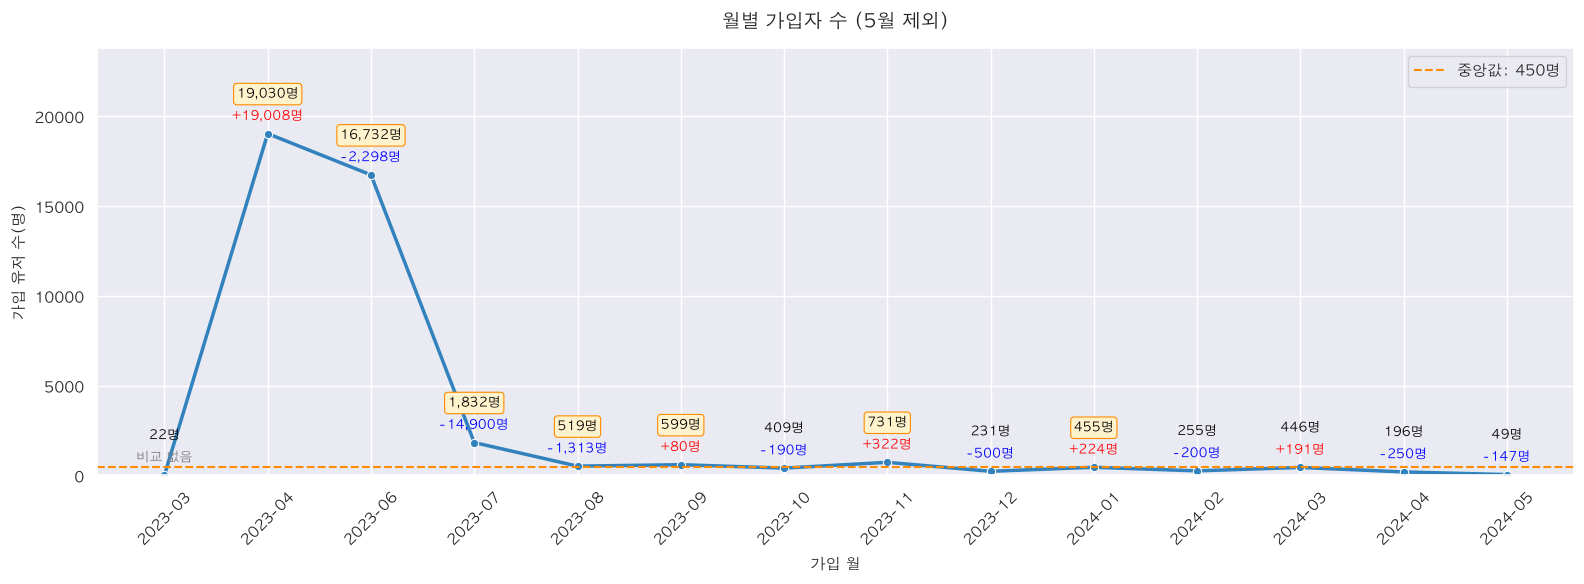

In [17]:
plot_monthly_signups(monthly_summary_ex_may, '월별 가입자 수 (5월 제외)')

💡 차트 설명
- **직전 표시 월 대비:** 직전 표시 월과 비교한 가입자 수 증감
  - 🔴 **빨강:** 직전 표시 월 대비 가입자 수 증가
  - 🔵 **파랑:** 직전 표시 월 대비 가입자 수 감소
- 🟨 **노란색 박스:** 전체 기간의 월별 가입자 수 **중앙값 이상을 기록한 월**

---

#### 월별 가입자 추이 확인
사용자 유입 측면에서 긍정적인 흐름을 보인 시점은 크게 세 가지 기준으로 구분할 수 있습니다.

* (1) **가입자 수가 다른 월 대비 두드러지게 높은 시기**: 2023년 4월, 5월, 6월<br>
* (2) **전월 대비 가입자 수가 증가한 달**: 2023년 4월, 5월, 9월, 11월 / 2024년 1월, 3월<br>
* (3) **가입자 수가 전체 기간 중앙값 이상인 달**: 2023년 4월~9월, 11월 / 2024년 1월<br>

#### 학사 일정과의 연관성 확인

**(2) 전월 대비 가입자 수가 증가한 시점**에 초점을 맞춰, 해당 시기의 증가가 **학사일정과 연관성이 있는지 확인**하고자 합니다.<br>

**(1), (3) 기준을 우선적으로 고려하지 않는 이유는 다음과 같습니다.**
- 서비스 출시 초기에는 초기 유입 효과로 인해 가입자 수가 일시적으로 크게 증가한 패턴이 포함되어 있습니다.
  - 서비스 출시 초기라고 판단한 근거는 `accounts_user` 전처리 수행 시 확인할 수 있던 내용으로, 서비스 내 가장 첫번째인 관리자 유저의 최초 계정 생성 시점이 '2023-03-29 03:44:14.047130+00:00'
- 이후에는 가입자 수가 장기적으로 감소하는 흐름을 보이고 있어, 단순히 가입자 규모가 크거나 중앙값 이상인 시점을 기준으로 비교할 경우 **초기 효과와 전체적인 감소 추세의 영향을 함께 받을 가능성**이 있습니다.
- 따라서 절대적인 가입자 규모보다는 **직전 월 대비 실제 유입이 증가한 시점**을 기준으로 학사일정과의 연관성을 탐색합니다.

#### 학사일정

- 학교의 학년도는 법령에 따라 **3월 1일부터 다음 해 2월 말까지**로 정해져 있으나, 세부적인 학기·수업일수·휴업일 등은 학교별로 차이가 있을 수 있습니다.

> **「초·중등교육법」 제24조(수업 등)**
>
> ① 학교의 학년도는 3월 1일부터 시작하여 다음 해 2월 말일까지로 한다.  
> ④ 학교의 학기·수업일수·학급편성·휴업일과 반의 편성·운영, 그 밖에 수업에 필요한 사항은 대통령령으로 정한다.

- 따라서 모든 학교에 동일한 세부 학사일정을 적용하기에는 한계가 있으므로, 본 분석에서는 **일반적인 중·고등학교의 학사일정을 참고하여 월별 가입자 추이와 비교**합니다.

- 아래 학사일정은 **가입자 추이와 학사일정 간의 전반적인 흐름을 탐색하기 위한 참고 자료**로, AI를 활용해 일반적인 중·고등학교의 학사일정을 정리하였습니다. 실제 일정은 학교별로 차이가 있을 수 있습니다.

| 시기 | 주요 학사일정 |
|---|---|
| **3월 초** | 입학식·시업식, 새 학년 시작 |
| **3~4월** | 정규수업, 학급·동아리 활동 시작 |
| **4월 말~5월 초** | 1학기 중간고사 |
| **5월** | 중간고사 이후 수업, 체육대회·체험활동 등 |
| **6월 말~7월 초** | 1학기 기말고사 |
| **7월 중·하순~8월 중·하순** | 여름방학 및 개학 |
| **8월 중·하순~9월** | 2학기 수업 시작 |
| **9월 말~10월** | 2학기 중간고사 |
| **10~11월** | 정규수업, 수학여행·체험활동 등 |
| **11월** | 대학수학능력시험 |
| **12월** | 2학기 기말고사, 학년말 활동 |
| **12월 말~2월** | 겨울방학, 종업·졸업, 학년말 방학 |

#### 💡 가입자 증가 시점과 학사일정 비교

전월 대비 가입자 수가 증가한 시점을 일반적인 학사일정과 비교하면 다음과 같습니다.

| 가입 증가 시점 | 일반적인 학사일정 | 해석 |
|---|---|---|
| **2023년 4월** | 정규수업 및 학급·동아리 활동 시작 | 새 학년 시작 이후 교내 관계 및 활동이 형성되는 시기 |
| **2023년 5월** | 중간고사 종료, 체육대회·체험활동 등 | 시험 이후 교내 활동이 활발해지는 시기 |
| **2023년 9월** | 2학기 수업 시작 | 2학기 개학 이후 학교생활이 다시 시작되는 시기 |
| **2023년 11월** | 정규수업 및 교내·체험활동 | 2학기 중간고사 이후 학교생활이 이어지는 시기 |
| **2024년 1월** | 겨울방학 및 학년말 기간 | 일반적인 학기 중 활동과는 거리가 있는 시기 |
| **2024년 3월** | 입학·개학 및 새 학년 시작 | 새로운 학급과 교우관계가 형성되는 시기 |

가입자가 증가한 6개 시점 중 **4월·5월·9월·11월·3월은 학기 시작 또는 학기 중 학교생활이 이루어지는 시기**라는 공통점을 확인할 수 있습니다.

특히 **3월·4월과 9월처럼 새로운 학기 또는 학년이 시작되는 시점 전후에 가입자 증가가 나타난 점**은 주목할 만합니다.

반면 **2024년 1월은 겨울방학 기간임에도 가입자가 증가**하여 학사일정만으로 모든 증가 시점을 설명하기에는 한계가 있습니다.

따라서 현재 단계에서는 **학교생활이 활발해지는 시점과 신규 가입자 증가 사이에 일정한 연관성이 나타날 가능성**을 확인할 수 있으나, 학사일정이 가입 증가의 직접적인 원인이라고 판단하기보다는 추가적인 요인과 함께 살펴볼 필요가 있습니다.

## 2. 가입자 구성 분석

In [18]:
school_summary = (
    df.groupby('school_type')['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

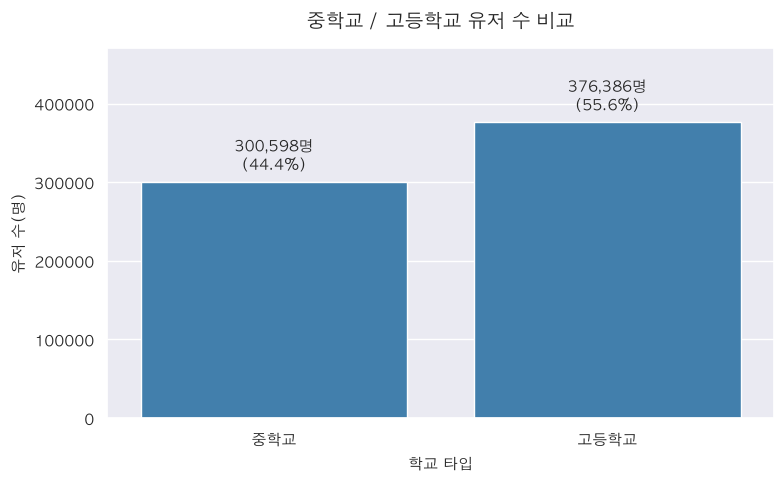

In [19]:
plt.figure(figsize=(8, 5))

# 막대그래프
ax = sns.barplot(
    data=school_summary,
    x='school_type',
    y='unique_users',
    order=['M', 'H'],
    color='#3182bd'
)

ax.set_xticks([0, 1], labels=['중학교', '고등학교'])

# 그래프에 표시된 학교급 전체 가입자 수 기준
total_users = school_summary['unique_users'].sum()

# 막대 위에 숫자 표시
for p in ax.patches:
    height = p.get_height()
    share = height / total_users * 100 if total_users else 0
    ax.annotate(
        f'{int(height):,}명\n({share:.1f}%)',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
    )

plt.title('중학교 / 고등학교 유저 수 비교', fontsize=14, pad=15)
plt.xlabel('학교 타입', fontsize=11)
plt.ylabel('유저 수(명)', fontsize=11)

# 위쪽 숫자가 잘리지 않도록 여유 공간
plt.ylim(0, school_summary['unique_users'].max() * 1.25)

plt.tight_layout()
plt.show()

In [20]:
# 학교급·학년별 고유 가입자 수 집계
school_grade_summary = (
    df.groupby(['school_type', 'grade'])['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

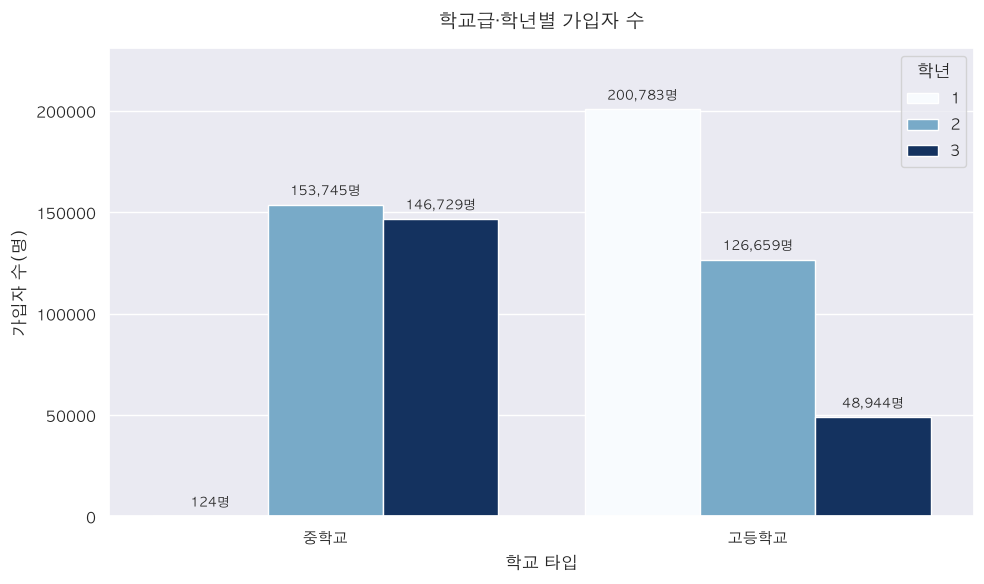

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=school_grade_summary,
    x='school_type',
    y='unique_users',
    hue='grade',
    order=['M', 'H'],
    palette='Blues',
    ax=ax,
)

ax.set_xticks([0, 1], labels=['중학교', '고등학교'])

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value:,.0f}명' for value in container.datavalues],
        padding=4,
        fontsize=9,
    )

ax.set_title('학교급·학년별 가입자 수', fontsize=14, pad=15)
ax.set_xlabel('학교 타입')
ax.set_ylabel('가입자 수(명)')
ax.legend(title='학년')
ax.set_ylim(0, school_grade_summary['unique_users'].max() * 1.15)

fig.tight_layout()
plt.show()


#### 💡 학교급 및 학년별 가입자 분포

- 서비스 가입자는 **중학생 44.4%(300,598명)**, **고등학생 55.6%(376,386명)**으로 구성되어 있어, 특정 학교급에 크게 편중되지 않고 중·고등학생 모두 고르게 이용하는 형태를 보입니다.

- 다만 학년별로 세분화하면 **중학교 2학년부터 고등학교 2학년까지의 가입자가 전체 가입자의 대부분을 차지**하고 있으며, 특히 **고등학교 1학년(200,783명)**의 가입자 수가 가장 많습니다.

- 이를 통해 서비스의 **핵심 사용자층은 중학교 2학년~고등학교 2학년 구간**에 형성되어 있음을 확인할 수 있습니다.

## 3. 학교 위치 별 유저 수 비교

In [22]:
# 학교 소재지 기준: 주소 공백 정리 및 지역 구분
area_df = df.copy()

address = (
    area_df['address']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)

parts = address.str.split(n=2, expand=True)

area_df['시도'] = parts[0].fillna('미상')
area_df['시군구'] = parts.reindex(columns=[1])[1].fillna('미기재')

# 시·도별 고유 가입자 수
region_summary = (
    area_df.groupby('시도')['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 시·도 + 시·군·구별 고유 가입자 수
city_summary = (
    area_df.groupby(['시도', '시군구'])['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 전체 고유 가입자 대비 지역별 비중
total_users = area_df['user_id'].nunique()

region_summary['비중(%)'] = (
    region_summary['가입자 수'] / total_users * 100
).round(2)

city_summary['비중(%)'] = (
    city_summary['가입자 수'] / total_users * 100
).round(2)

# display(region_summary)
# display(city_summary)


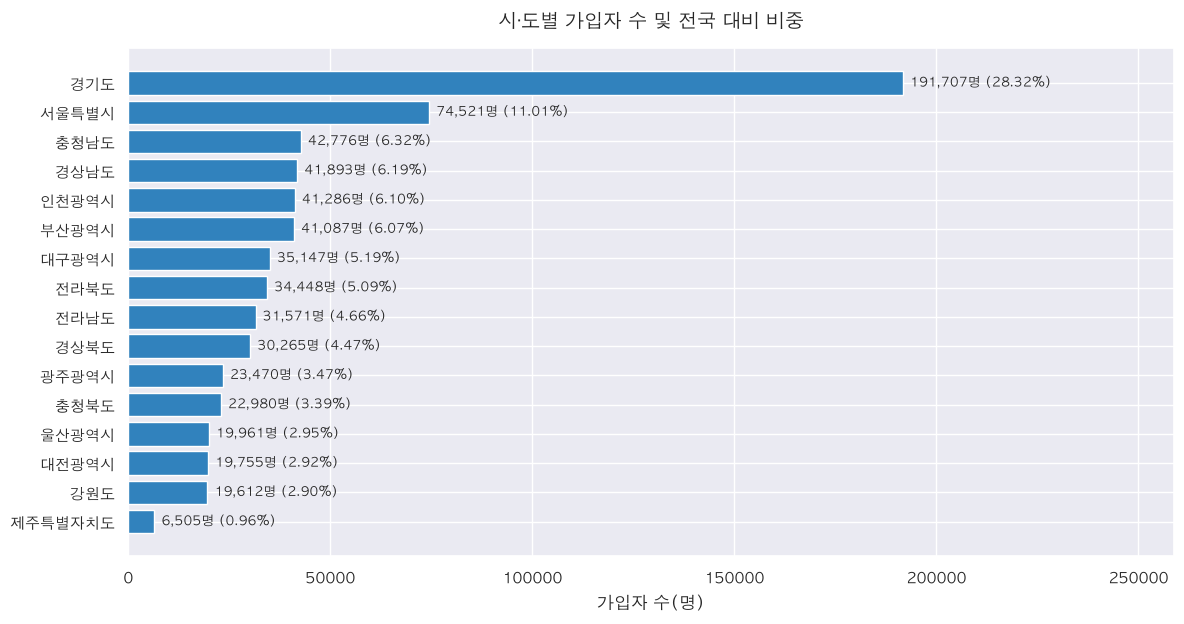

In [23]:
plot_area_signups(
    region_summary.sort_values('가입자 수', ascending=False),
    '시도',
    '시·도별 가입자 수 및 전국 대비 비중',
)

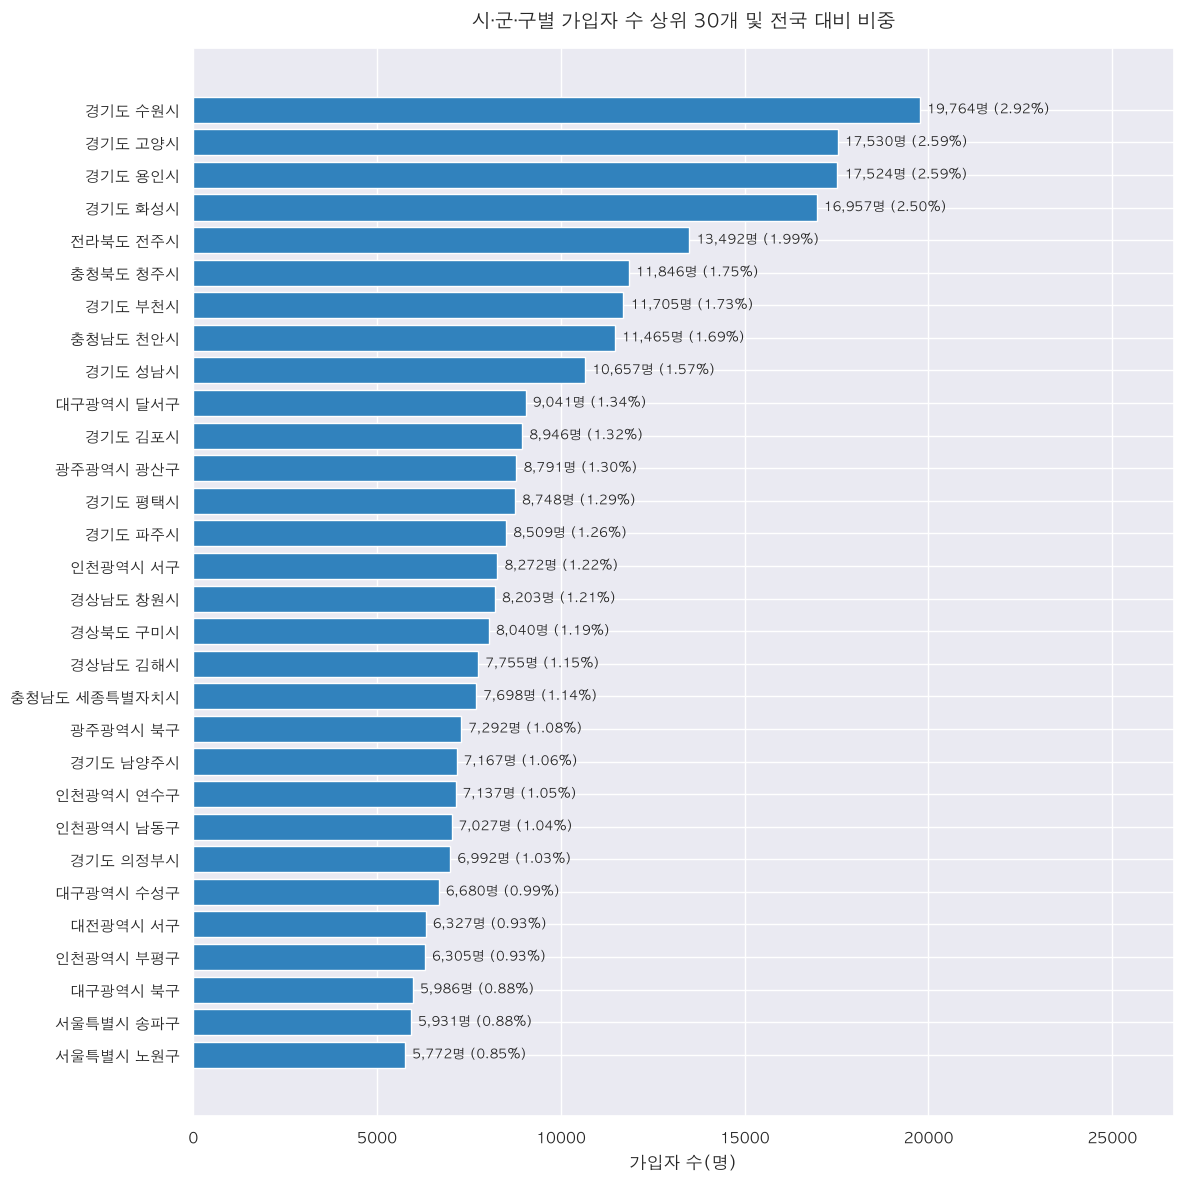

In [24]:
city_top30 = (
    city_summary.nlargest(30, '가입자 수')
    .copy()
)

city_top30['지역'] = city_top30['시도'] + ' ' + city_top30['시군구']

plot_area_signups(
    city_top30,
    '지역',
    '시·군·구별 가입자 수 상위 30개 및 전국 대비 비중',
)

#### 💡 학교 위치별 가입자 분포

- **경기도**는 전체 가입자의 약 **28%**를 차지하며, 가장 많은 가입자가 분포한 지역입니다.

- 그다음으로 **서울(약 11%)**이 높은 비중을 차지하며, 충청남도, 경상남도, 인천, 부산, 대구 순으로 이어집니다.

- 다만 **시·군·구 단위로 세분화하면 다른 양상**을 확인할 수 있습니다. 서울은 광역 단위에서는 두 번째로 가입자가 많지만, 개별 행정구는 가입자 수 기준 상위권에서 상대적으로 적게 나타납니다.

- 이를 통해 서울은 **특정 행정구에 가입자가 집중되기보다는 여러 행정구에 비교적 분산되어 있을 가능성**을 생각해볼 수 있습니다.

### 지역별 가입자 편차 비교

In [25]:
# 전체 시·군·구별 가입자 수의 평균과 중앙값
# 시·도별 평균의 평균이 아니라, city_summary 전체 행을 기준으로 계산합니다.
overall_area_summary = pd.DataFrame([{
    '기준': '전체 시·군·구 (현재 집계 기준)',
    '시군구수': len(city_summary),
    '평균': city_summary['가입자 수'].mean(),
    '중앙값': city_summary['가입자 수'].median(),
}])

display(
    overall_area_summary.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}'}
    )
)

# 시·도 내 시·군·구별 가입자 수의 표준편차가 작은 순서
# 현재 집계에 포함된 지역 기준이며, 가입자가 없는 미관측 지역은 포함하지 않습니다.
region_dispersion = (
    city_summary.groupby('시도')['가입자 수']
    .agg(
        시군구수='size',
        평균='mean',
        중앙값='median',
        표준편차=lambda values: values.std(ddof=0),
    )
    .reset_index()
)

# 비교 대상이 하나뿐인 지역은 순위를 매기지 않습니다.
comparable = region_dispersion['시군구수'].ge(2)
region_dispersion.loc[~comparable, '표준편차'] = float('nan')
region_dispersion['순위'] = (
    region_dispersion['표준편차'].rank(method='min').astype('Int64')
)
region_dispersion = (
    region_dispersion.sort_values(['표준편차', '시도'], na_position='last')
    [['순위', '시도', '시군구수', '평균', '중앙값', '표준편차']]
    .reset_index(drop=True)
)

display(
    region_dispersion.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}', '표준편차': '{:,.1f}'},
        na_rep='비교 제외',
    )
)



,기준,시군구수,평균,중앙값
0,전체 시·군·구 (현재 집계 기준),229,"2,956.3","1,943.0"


,순위,시도,시군구수,평균,중앙값,표준편차
0,1,울산광역시,5,"3,992.2","3,800.0",684.5
1,2,서울특별시,25,"2,980.8","2,592.0","1,309.4"
2,3,강원도,18,"1,089.6",530.5,"1,415.4"
3,4,전라남도,22,"1,435.0",671.0,"1,580.1"
4,5,대전광역시,5,"3,951.0","3,236.0","1,595.6"
5,6,부산광역시,16,"2,567.9","1,934.0","1,602.5"
6,7,경상북도,23,"1,315.9",525.0,"1,725.4"
7,8,제주특별자치도,2,"3,252.5","3,252.5","2,384.5"
8,9,대구광역시,8,"4,393.4","3,851.5","2,469.7"
9,10,경상남도,18,"2,327.4","1,208.0","2,513.1"


#### 💡 지역별 가입자 분포 및 편차

- 시·도별 **시·군·구 가입자 수의 표준편차**를 비교한 결과, 서울은 오름차순 기준 **두 번째로 낮은 표준편차**를 기록했습니다. 이를 통해 서울의 가입자가 특정 행정구에 집중되기보다는 **지역별로 비교적 고르게 분포되어 있다는 앞선 가설을 확인**할 수 있었습니다.

- 또한 서울은 개별 행정구의 가입자 수가 두드러지게 높지는 않지만, **다수의 행정구에서 비교적 고르게 가입자를 확보하면서 전체 가입자 수 기준 2위**를 기록한 것으로 볼 수 있습니다.

- 반면 **경기도는 시·군·구별 가입자 수의 편차가 상대적으로 크게 나타났습니다.** 즉, 일부 지역에 가입자가 집중되는 경향이 존재하지만, 동시에 **다수의 행정구역에서 많은 가입자를 확보하면서 전체 가입자 수 기준 가장 높은 비중(약 28%)**을 차지한 것으로 보입니다.

## 4. 집단 가입 패턴 및 확산 속도 분석

동일 학급 내 사용자들의 가입 시점을 비교하여, **특정 시간 내 가입이 집중되는 집단 가입 패턴이 존재하는지 확인**합니다.

### 분석 가정

- 학급(`group_id`) 변경을 위해서는 학생증 등의 증빙 절차가 필요하므로, **사용자의 학급 정보가 빈번하게 변경되기 어려운 구조**라고 판단했습니다.
- 이에 따라 현재 기록된 `group_id`가 **가입 당시에도 동일했다고 가정**하여 분석을 진행합니다.
- 또한 기획서상 연도 변경 시점의 학급 변경 Flow를 확인하기 어려워, **학년 변경 등에 따른 `group_id` 변동 가능성은 본 분석에서 고려하지 않습니다.**

### 4-1. 학급별 집단 가입 패턴 확인

#### 분석 기준

- **고유 가입자가 4명 이상인 그룹**을 분석 대상으로 설정합니다.
- 각 그룹에서 연속된 **24시간 내 최대 가입자 수**와 **가입 집중도**를 계산합니다.
- **가입 집중도**는 해당 그룹의 전체 관측 가입자 중 특정 24시간 내 가입한 사용자의 비율을 의미하며, **실제 학급 정원 대비 가입률은 아닙니다.**
- 24시간 구간은 **시작 시각 이상, 종료 시각 미만**을 기준으로 하며, 최대 가입자 수가 동일한 구간이 여러 개 존재할 경우 **가장 이른 구간을 선택**합니다.

> **해석 시 유의사항**  
> `4명 이상`과 `24시간`은 집단 가입 패턴을 탐색하기 위해 설정한 기준입니다. 따라서 특정 시간 내 가입이 집중되었다는 결과만으로 **친구 초대, 입소문 등의 구체적인 유입 원인을 확정하지 않습니다.**

In [26]:
group_burst_summary, group_coverage = analyze_signup_bursts(
    df,
    entity_col='group_id',
    min_users=4,
    window_hours=24,
)

display(group_coverage)
display(group_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,80891
1,분석 대상 집단,56956
2,최소 인원 미달 집단,23935


,group_id,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,43124,24,24,100.0,2023-05-11 01:12:49.669935+00:00,2023-05-12 01:12:49.669935+00:00,2023-05-11 01:12:49.669935+00:00,2023-05-12 00:57:01.749899+00:00
1,38756,22,22,100.0,2023-05-17 01:11:49.634726+00:00,2023-05-18 01:11:49.634726+00:00,2023-05-17 01:11:49.634726+00:00,2023-05-17 11:06:57.134108+00:00
2,41875,22,22,100.0,2023-05-10 11:32:11.607936+00:00,2023-05-11 11:32:11.607936+00:00,2023-05-10 11:32:11.607936+00:00,2023-05-11 09:36:33.179702+00:00
3,52751,21,21,100.0,2023-05-13 03:44:50.520752+00:00,2023-05-14 03:44:50.520752+00:00,2023-05-13 03:44:50.520752+00:00,2023-05-13 16:23:17.516385+00:00
4,11500,20,20,100.0,2023-05-06 11:26:30.975532+00:00,2023-05-07 11:26:30.975532+00:00,2023-05-06 11:26:30.975532+00:00,2023-05-07 08:18:16.258602+00:00


In [27]:
group_distribution = summarize_burst_distribution(
    group_burst_summary,
    entity_label='학급',
    window_hours=24,
)

display(group_distribution)

,24시간 가입 집중도 구간,학급 수,학급 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,486,0.85
2,20~30% 미만,5894,10.35
3,30~40% 미만,9817,17.24
4,40~50% 미만,10912,19.16
5,50~60% 미만,12647,22.20
6,60~70% 미만,7592,13.33
7,70~80% 미만,4972,8.73
8,80~90% 미만,3082,5.41
9,90~100%,1554,2.73


#### 💡 집단 가입 집중도 분석

- 가입 집중도는 **40~60% 구간에 가장 많은 그룹이 분포**하며, 특히 **50~60% 구간이 22.20%로 가장 높은 비중**을 차지합니다.

- 전체 그룹의 약 **71.6%가 가입 집중도 40% 이상**, 약 **52.4%가 50% 이상**으로 나타났습니다. 즉, 상당수 그룹에서 **관측된 가입자의 절반가량이 특정 24시간 내 집중적으로 가입하는 패턴**을 확인할 수 있습니다.

- 특히 가입 집중도가 **70% 이상인 그룹도 약 16.9%** 존재하여, 일부 그룹에서는 구성원의 상당수가 짧은 시간 내 연속적으로 가입하는 강한 집단 가입 패턴이 나타납니다.

- 이를 통해 서비스 가입이 사용자별로 독립적으로 발생하기보다는, **동일 학급 내에서 특정 시점을 중심으로 가입이 집중되는 경향이 존재할 가능성**을 확인할 수 있습니다.

### 4-2. 학교별 집단 가입 패턴 확인

#### 분석 기준

- **고유 가입자가 40명 이상인 학교**을 분석 대상으로 설정합니다.
- 각 그룹에서 연속된 **72시간 내 최대 가입자 수**와 **가입 집중도**를 계산합니다.
- **가입 집중도**는 해당 그룹의 전체 관측 가입자 중 특정 72시간 내 가입한 사용자의 비율을 의미하며, **실제 학급 정원 대비 가입률은 아닙니다.**
- 72시간 구간은 **시작 시각 이상, 종료 시각 미만**을 기준으로 하며, 최대 가입자 수가 동일한 구간이 여러 개 존재할 경우 **가장 이른 구간을 선택**합니다.

> **해석 시 유의사항**  
> `40명 이상`과 `72시간`은 집단 가입 패턴을 탐색하기 위해 설정한 기준입니다. 따라서 특정 시간 내 가입이 집중되었다는 결과만으로 **친구 초대, 입소문 등의 구체적인 유입 원인을 확정하지 않습니다.**

In [28]:
school_burst_summary, school_coverage = analyze_signup_bursts(
    df,
    entity_col='school_id',
    min_users=40,
    window_hours=72,
)

display(school_coverage)
display(school_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,5548
1,분석 대상 집단,3896
2,최소 인원 미달 집단,1652


,school_id,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,3706,53,53,100.000000,2023-05-29 10:40:47.752915+00:00,2023-06-01 10:40:47.752915+00:00,2023-05-29 10:40:47.752915+00:00,2023-05-30 22:31:36.762446+00:00
1,1891,69,68,98.550725,2023-05-06 02:10:46.685623+00:00,2023-05-09 02:10:46.685623+00:00,2023-05-06 02:10:46.685623+00:00,2023-05-19 12:38:55.364632+00:00
2,5957,136,132,97.058824,2023-05-15 15:26:40.338277+00:00,2023-05-18 15:26:40.338277+00:00,2023-05-13 04:24:46.791535+00:00,2023-05-23 22:10:54.245575+00:00
3,4403,132,128,96.969697,2023-05-09 14:12:00.305554+00:00,2023-05-12 14:12:00.305554+00:00,2023-05-05 08:13:21.316376+00:00,2023-05-13 15:02:37.269468+00:00
4,878,200,193,96.500000,2023-05-16 12:53:40.293467+00:00,2023-05-19 12:53:40.293467+00:00,2023-05-07 03:20:55.877691+00:00,2024-03-31 15:25:42.102031+00:00


In [29]:
school_distribution = summarize_burst_distribution(
    school_burst_summary,
    entity_label='학교',
    window_hours=72,
)

display(school_distribution)

,72시간 가입 집중도 구간,학교 수,학교 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,3,0.08
2,20~30% 미만,152,3.90
3,30~40% 미만,478,12.27
4,40~50% 미만,706,18.12
5,50~60% 미만,781,20.05
6,60~70% 미만,772,19.82
7,70~80% 미만,651,16.71
8,80~90% 미만,313,8.03
9,90~100%,40,1.03


#### 💡 학교 단위 72시간 가입 집중도 분석

- 학교별 가입 집중도는 **50~60% 구간이 20.05%로 가장 높은 비중**을 차지하며, 60~70%(19.82%), 40~50%(18.12%), 70~80%(16.71%) 순으로 나타났습니다.

- 전체 학교의 약 **65.6%에서 관측 가입자의 절반 이상이 특정 72시간 내 가입**한 것으로 나타났으며, 약 **45.6%는 60% 이상의 가입자가 72시간 내 집중적으로 가입**했습니다.

- 특히 가입 집중도가 **70% 이상인 학교도 약 25.8%**로 나타나, 일부 학교에서는 가입자의 상당수가 짧은 기간 내 집중적으로 유입되는 패턴을 확인할 수 있습니다.

- 반면 가입 집중도가 **30% 미만인 학교는 약 4.0%**에 불과하여, 가입이 장기간에 걸쳐 분산되기보다는 **특정 시기를 중심으로 집중되는 학교가 상대적으로 많은 형태**를 보입니다.

- 이를 통해 개별 사용자의 가입이 독립적으로 발생하는 것뿐만 아니라, **학교 단위에서도 일정 기간 내 가입이 집중되는 확산 패턴이 존재할 가능성**을 확인할 수 있습니다.

### 4-3. 도시(시군구)별 집단 가입 패턴 확인

In [30]:
city_data = area_df.copy()
city_data['지역'] = city_data['시도'] + ' ' + city_data['시군구']

city_burst_summary, city_coverage = analyze_signup_bursts(
    city_data,
    entity_col='지역',
    min_users=40,
    window_hours=72,
)

display(city_coverage)
display(city_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,229
1,분석 대상 집단,226
2,최소 인원 미달 집단,3


,지역,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,경상남도 함양군,657,536,81.582953,2023-05-21 10:41:05.424898+00:00,2023-05-24 10:41:05.424898+00:00,2023-05-06 14:00:12.914564+00:00,2023-06-19 22:28:03.028131+00:00
1,전라북도 순창군,535,435,81.308411,2023-05-22 10:15:04.989666+00:00,2023-05-25 10:15:04.989666+00:00,2023-05-03 13:00:30.512301+00:00,2023-12-26 12:29:44.452839+00:00
2,울산광역시 동구,3434,2559,74.519511,2023-05-06 12:03:45.789199+00:00,2023-05-09 12:03:45.789199+00:00,2023-04-26 12:02:06.601496+00:00,2024-03-30 13:25:20.197416+00:00
3,경기도 연천군,521,375,71.976967,2023-05-09 12:01:11.900879+00:00,2023-05-12 12:01:11.900879+00:00,2023-05-04 03:41:50.253075+00:00,2024-04-24 12:40:41.958836+00:00
4,전라남도 화순군,1291,867,67.157242,2023-05-20 02:02:46.100655+00:00,2023-05-23 02:02:46.100655+00:00,2023-04-20 15:48:09.816573+00:00,2024-03-09 14:47:38.220253+00:00


In [31]:
city_distribution = summarize_burst_distribution(
    city_burst_summary,
    entity_label='도시',
    window_hours=72,
)

display(city_distribution)

,72시간 가입 집중도 구간,도시 수,도시 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,10,4.42
2,20~30% 미만,59,26.11
3,30~40% 미만,66,29.20
4,40~50% 미만,49,21.68
5,50~60% 미만,29,12.83
6,60~70% 미만,9,3.98
7,70~80% 미만,2,0.88
8,80~90% 미만,2,0.88
9,90~100%,0,0.00


### 4-4. 지역(시도)별 집단 가입 패턴 확인

In [32]:
region_burst_summary, region_coverage = analyze_signup_bursts(
    area_df,
    entity_col='시도',
    min_users=40,
    window_hours=72,
)

display(region_coverage)
display(region_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,16
1,분석 대상 집단,16
2,최소 인원 미달 집단,0


,시도,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,충청북도,22980,8179,35.591819,2023-05-06 00:46:25.019348+00:00,2023-05-09 00:46:25.019348+00:00,2023-04-04 03:19:12.336682+00:00,2024-05-06 13:48:40.161236+00:00
1,경기도,191707,67319,35.115567,2023-05-06 12:22:55.615616+00:00,2023-05-09 12:22:55.615616+00:00,2023-03-31 09:05:51.903699+00:00,2024-05-07 11:57:29.459197+00:00
2,광주광역시,23470,7858,33.481040,2023-05-13 10:22:50.955585+00:00,2023-05-16 10:22:50.955585+00:00,2023-04-20 13:46:23.302662+00:00,2024-05-03 12:29:46.469304+00:00
3,울산광역시,19961,6093,30.524523,2023-05-09 10:47:37.070973+00:00,2023-05-12 10:47:37.070973+00:00,2023-04-21 09:27:54.389241+00:00,2024-04-11 15:41:09.267276+00:00
4,인천광역시,41286,11939,28.917793,2023-05-11 06:26:56.825331+00:00,2023-05-14 06:26:56.825331+00:00,2023-04-11 02:15:46.781874+00:00,2024-04-28 14:40:07.345830+00:00


In [33]:
region_distribution = summarize_burst_distribution(
    region_burst_summary,
    entity_label='지역',
    window_hours=72,
)

display(region_distribution)

,72시간 가입 집중도 구간,지역 수,지역 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,1,6.25
2,20~30% 미만,11,68.75
3,30~40% 미만,4,25.00
4,40~50% 미만,0,0.00
5,50~60% 미만,0,0.00
6,60~70% 미만,0,0.00
7,70~80% 미만,0,0.00
8,80~90% 미만,0,0.00
9,90~100%,0,0.00


### 4-5. 인접학교 간 집단가입 시간 차

In [34]:
nearby_sql = f"""
    SELECT school_id, nearby_school_id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_nearbyschool`
"""

nearby_raw = client.query(nearby_sql).to_dataframe()

nearby_valid = (
    nearby_raw
    .dropna(subset=['school_id', 'nearby_school_id'])
    .copy()
)

# 자기 자신과 연결된 관계 제외
nearby_valid = nearby_valid[
    nearby_valid['school_id'].ne(nearby_valid['nearby_school_id'])
]

# A→B, B→A를 동일한 학교 쌍으로 정리
nearby_pairs = pd.DataFrame({
    'school_a': nearby_valid[
        ['school_id', 'nearby_school_id']
    ].min(axis=1),
    'school_b': nearby_valid[
        ['school_id', 'nearby_school_id']
    ].max(axis=1),
}).drop_duplicates().reset_index(drop=True)

print(f'원본 관계: {len(nearby_raw):,}행')
print(f'중복 제거 후 인접 학교 쌍: {len(nearby_pairs):,}개')

원본 관계: 66,696행
중복 제거 후 인접 학교 쌍: 33,348개


In [35]:
school_stats = school_burst_summary[[
    'school_id',
    '가입자 수',
    '가입 집중도(%)',
    '집중 구간 시작',
    '집중 구간 종료(미포함)',
]].copy()

# 기존 결과가 실제로 40명 이상·72시간 조건인지 확인
if school_stats['school_id'].duplicated().any():
    raise ValueError('학교별 집중도 결과에 중복 school_id가 있습니다.')

if school_stats['가입자 수'].lt(40).any():
    raise ValueError('학교 가입자 40명 이상 조건을 확인해 주세요.')

window_lengths = (
    school_stats['집중 구간 종료(미포함)']
    - school_stats['집중 구간 시작']
)
if not window_lengths.eq(pd.Timedelta(hours=72)).all():
    raise ValueError('school_burst_summary가 72시간 기준인지 확인해 주세요.')


def attach_school_stats(pairs, stats, suffix):
    renamed = stats.rename(columns={
        'school_id': f'school_{suffix}',
        '가입자 수': f'{suffix}_가입자 수',
        '가입 집중도(%)': f'{suffix}_집중도(%)',
        '집중 구간 시작': f'{suffix}_시작',
        '집중 구간 종료(미포함)': f'{suffix}_종료',
    })

    return pairs.merge(
        renamed,
        on=f'school_{suffix}',
        how='inner',
        validate='many_to_one',
    )


pair_comparison = attach_school_stats(nearby_pairs, school_stats, 'a')
pair_comparison = attach_school_stats(pair_comparison, school_stats, 'b')

display(pd.DataFrame({
    '구분': ['전체 인접 학교 쌍', '분석 대상 학교 쌍', '한쪽 이상 분석 대상 아님'],
    '학교 쌍 수': [
        len(nearby_pairs),
        len(pair_comparison),
        len(nearby_pairs) - len(pair_comparison),
    ],
}))

,구분,학교 쌍 수
0,전체 인접 학교 쌍,33348
1,분석 대상 학교 쌍,16890
2,한쪽 이상 분석 대상 아님,16458


In [36]:
pair_comparison['집중 시작 시차(시간)'] = (
    (pair_comparison['a_시작'] - pair_comparison['b_시작'])
    .abs()
    .dt.total_seconds()
    / 3600
)

# 두 구간 중 늦은 시작과 이른 종료를 이용
overlap_start = pair_comparison['a_시작'].where(
    pair_comparison['a_시작'].ge(pair_comparison['b_시작']),
    pair_comparison['b_시작'],
)

overlap_end = pair_comparison['a_종료'].where(
    pair_comparison['a_종료'].le(pair_comparison['b_종료']),
    pair_comparison['b_종료'],
)

pair_comparison['집중 구간 중첩(시간)'] = (
    (overlap_end - overlap_start)
    .dt.total_seconds()
    .div(3600)
    .clip(lower=0)
)

In [37]:
school_events = (
    df[['user_id', 'school_id', 'signup_date']]
    .dropna(subset=['user_id', 'school_id', 'signup_date'])
    .sort_values('signup_date')
    .drop_duplicates(['school_id', 'user_id'], keep='first')
)

school_times = {
    school_id: pd.DatetimeIndex(group['signup_date']).sort_values()
    for school_id, group in school_events.groupby('school_id')
}

# 집중도 결과와 현재 df의 학교별 가입자 수가 일치하는지 확인
for _, school in school_stats.iterrows():
    times = school_times.get(school['school_id'])
    if times is None or len(times) != school['가입자 수']:
        raise ValueError(
            'df와 school_burst_summary의 대상 데이터가 다릅니다. '
            '학교 집중도를 다시 계산해 주세요.'
        )


def signup_share_in_window(times, start, end):
    left = times.searchsorted(start, side='left')
    right = times.searchsorted(end, side='left')
    return (right - left) / len(times) * 100


a_during_b = []
b_during_a = []

for _, pair in pair_comparison.iterrows():
    a_during_b.append(signup_share_in_window(
        school_times[pair['school_a']],
        pair['b_시작'],
        pair['b_종료'],
    ))

    b_during_a.append(signup_share_in_window(
        school_times[pair['school_b']],
        pair['a_시작'],
        pair['a_종료'],
    ))

pair_comparison['B 집중 구간 내 A 가입 비중(%)'] = a_during_b
pair_comparison['A 집중 구간 내 B 가입 비중(%)'] = b_during_a

pair_comparison = (
    pair_comparison
    .sort_values(
        ['집중 구간 중첩(시간)', '집중 시작 시차(시간)'],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(pair_comparison.head(5))

,school_a,school_b,a_가입자 수,a_집중도(%),a_시작,a_종료,b_가입자 수,b_집중도(%),b_시작,b_종료,집중 시작 시차(시간),집중 구간 중첩(시간),B 집중 구간 내 A 가입 비중(%),A 집중 구간 내 B 가입 비중(%)
0,1757,1758,165,69.696970,2023-05-07 07:59:38.027097+00:00,2023-05-10 07:59:38.027097+00:00,175,72.571429,2023-05-07 07:59:37.840859+00:00,2023-05-10 07:59:37.840859+00:00,0.000052,71.999948,69.696970,72.000000
1,5657,5846,43,55.813953,2023-05-23 14:34:16.537873+00:00,2023-05-26 14:34:16.537873+00:00,88,75.000000,2023-05-23 14:34:17.618879+00:00,2023-05-26 14:34:17.618879+00:00,0.000300,71.999700,53.488372,75.000000
2,3467,3483,344,63.081395,2023-05-11 14:29:02.428926+00:00,2023-05-14 14:29:02.428926+00:00,308,66.558442,2023-05-11 14:29:04.232887+00:00,2023-05-14 14:29:04.232887+00:00,0.000501,71.999499,62.790698,66.558442
3,5789,5796,228,63.157895,2023-05-22 06:56:33.698352+00:00,2023-05-25 06:56:33.698352+00:00,261,55.938697,2023-05-22 06:56:41.168159+00:00,2023-05-25 06:56:41.168159+00:00,0.002075,71.997925,62.719298,55.938697
4,5207,5219,174,60.344828,2023-05-06 07:32:41.805105+00:00,2023-05-09 07:32:41.805105+00:00,118,46.610169,2023-05-06 07:32:33.745123+00:00,2023-05-09 07:32:33.745123+00:00,0.002239,71.997761,60.344828,45.762712


,집중 시작 시차,학교 쌍 수,학교 쌍 비중(%)
0,24시간 미만,5800,34.34
1,24~72시간 미만,4694,27.79
2,72~168시간 미만,3489,20.66
3,168시간 이상,2907,17.21


,분석 학교 쌍 수,집중 시작 시차 중앙값(시간),집중 구간이 겹치는 쌍 비중(%)
0,16890,46.73,62.13


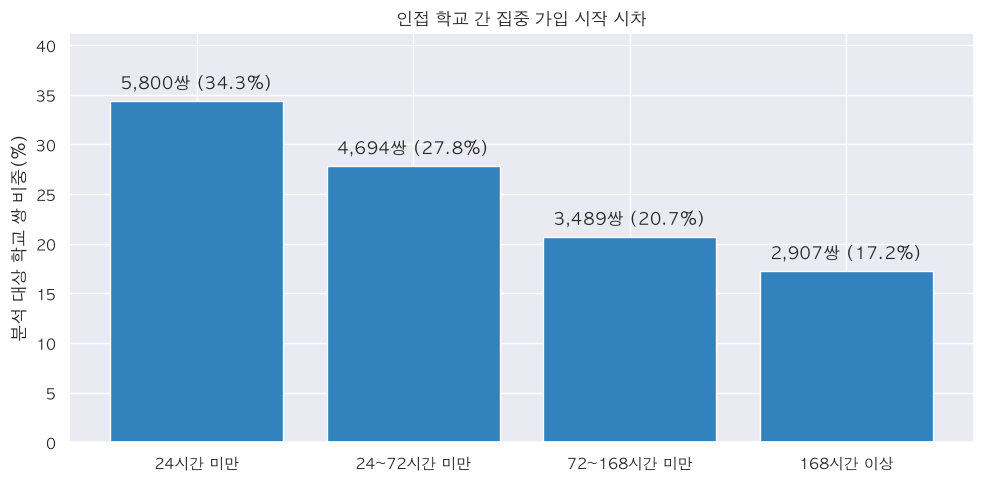

In [38]:
gap_labels = [
    '24시간 미만',
    '24~72시간 미만',
    '72~168시간 미만',
    '168시간 이상',
]

gap_distribution = (
    pd.cut(
        pair_comparison['집중 시작 시차(시간)'],
        bins=[0, 24, 72, 168, float('inf')],
        labels=gap_labels,
        right=False,
    )
    .value_counts(sort=False)
    .rename_axis('집중 시작 시차')
    .reset_index(name='학교 쌍 수')
)

pair_count = len(pair_comparison)

gap_distribution['학교 쌍 비중(%)'] = (
    (gap_distribution['학교 쌍 수'] / pair_count * 100).round(2)
    if pair_count else float('nan')
)

display(gap_distribution)

if pair_count:
    display(pd.DataFrame([{
        '분석 학교 쌍 수': pair_count,
        '집중 시작 시차 중앙값(시간)':
            pair_comparison['집중 시작 시차(시간)'].median(),
        '집중 구간이 겹치는 쌍 비중(%)':
            pair_comparison['집중 구간 중첩(시간)'].gt(0).mean() * 100,
    }]).round(2))

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(
        gap_distribution['집중 시작 시차'].astype(str),
        gap_distribution['학교 쌍 비중(%)'],
        color='#3182bd',
    )
    ax.bar_label(
        bars,
        labels=[
            f'{count:,}쌍 ({share:.1f}%)'
            for count, share in zip(
                gap_distribution['학교 쌍 수'],
                gap_distribution['학교 쌍 비중(%)'],
            )
        ],
        padding=5,
    )

    ax.set_title('인접 학교 간 집중 가입 시작 시차')
    ax.set_ylabel('분석 대상 학교 쌍 비중(%)')
    ax.set_ylim(
        0,
        gap_distribution['학교 쌍 비중(%)'].max() * 1.2,
    )

    fig.tight_layout()
    plt.show()

## 5. 가입자 별 결제 규모 파악

In [39]:
# 전처리 수행 대상 테이블 호출
sql2 = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_paymenthistory` AS p
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user` AS u
    ON p.user_id = u.user_id
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.product_price` AS pp
    ON p.productId = pp.product_id
"""

# 판다스 데이터프레임으로 변환
df2 = client.query(sql2).to_dataframe()

print(df2.head())

      id  productId phone_type                created_at  user_id  user_id_1  \
0  97315  heart.777          I 2023-11-12 06:03:43+00:00   937054     937054   
1  96875  heart.777          I 2023-09-21 15:06:00+00:00  1173477    1173477   
2  96876  heart.777          I 2023-09-21 15:06:00+00:00  1173477    1173477   
3  48708  heart.777          I 2023-05-21 11:34:09+00:00  1230722    1230722   
4  50561  heart.200          I 2023-05-21 15:03:42+00:00  1230722    1230722   

                       signup_date  group_id  grade  school_id      address  \
0 2023-05-07 02:35:24.651241+00:00     19147      2       2226    서울특별시 동작구   
1 2023-05-12 12:05:06.366820+00:00     21723      3       4961  경기도 안양시 동안구   
2 2023-05-12 12:05:06.366820+00:00     21723      3       4961  경기도 안양시 동안구   
3 2023-05-13 14:38:22.309286+00:00     41456      3       3860     경상북도 구미시   
4 2023-05-13 14:38:22.309286+00:00     41456      3       3860     경상북도 구미시   

  school_type product_id  price  
0         

## 학교급별 결제 금액 차이

In [52]:
df2.groupby('school_type')['price'].sum().reset_index(name='결제금액')

,school_type,결제금액
0,H,132220700
1,M,69076100


In [40]:
# 지역별 결제 규모: 학교 소재지 및 상품 가격 기준
# 동일 결제 ID가 조인으로 증식했는지 확인
if df2['id'].duplicated().any():
    raise ValueError(
        '같은 결제 ID가 여러 행에 존재합니다. '
        '사용자·상품 가격 테이블의 조인 중복을 확인해 주세요.'
    )

# 기존 전처리 기준: 동일 유저·동일 시각은 최초 ID 한 건만 인정
payment_area = (
    df2.sort_values('id')
    .drop_duplicates(['user_id', 'created_at'], keep='first')
    .copy()
)

# ARPU 분모는 미결제자를 포함한 전체 가입자이며, 지역은 동일한 사용자 기준으로 연결
payment_user_base = df[['user_id', 'address']].drop_duplicates().copy()
if payment_user_base['user_id'].duplicated().any():
    raise ValueError('동일 유저에 여러 주소가 연결되어 있습니다. 지역 귀속 기준을 확인해 주세요.')

address = (
    payment_user_base['address'].astype('string').str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)
parts = address.str.split(n=2, expand=True).reindex(columns=[0, 1])
payment_user_base['시도'] = parts[0].fillna('미상')
payment_user_base['시군구'] = parts[1].fillna('미기재')

payment_area = payment_area.merge(
    payment_user_base[['user_id', '시도', '시군구']],
    on='user_id', how='left', validate='many_to_one', indicator=True,
)
if payment_area['_merge'].ne('both').any():
    raise ValueError('전체 가입자 데이터에 없는 결제자가 있습니다. df와 df2의 대상 범위를 확인해 주세요.')
payment_area = payment_area.drop(columns='_merge')

# 분모는 df2에 연결된 결제의 중복 정리 후 총금액
# INNER JOIN 미연결 결제는 포함되지 않으며, 환불 반영 순매출과 구분합니다.
total_payment = payment_area['price'].sum()

# 조회된 누적 결제금액 / 전체 가입자 기준이며, 월간 활성 사용자 기준 ARPU가 아닙니다.
def summarize_area_payment(data, group_cols):
    user_counts = (
        payment_user_base.groupby(group_cols)['user_id']
        .nunique().reset_index(name='가입자수')
    )
    payments = (
        data.groupby(group_cols)
        .agg(
            결제금액=('price', 'sum'),
            결제건수=('id', 'nunique'),
            결제자수=('user_id', 'nunique'),
        )
        .reset_index()
    )
    # 결제 이력이 없는 지역도 포함
    summary = user_counts.merge(
        payments, on=group_cols, how='left', validate='one_to_one'
    )
    payment_cols = ['결제금액', '결제건수', '결제자수']
    summary[payment_cols] = summary[payment_cols].fillna(0)
    summary[['결제건수', '결제자수']] = summary[['결제건수', '결제자수']].astype(int)

    summary['결제금액 비중(%)'] = (
        (summary['결제금액'] / total_payment * 100).round(2)
        if total_payment > 0 else float('nan')
    )
    summary['ARPU'] = (
        summary['결제금액'] / summary['가입자수'].replace(0, float('nan'))
    ).round(2)
    summary['ARPPU'] = (
        summary['결제금액'] / summary['결제자수'].replace(0, float('nan'))
    ).round(2)
    summary['결제 전환율(%)'] = (
        summary['결제자수']
        / summary['가입자수'].replace(0, float('nan'))
        * 100
    ).round(2)
    return summary.sort_values('결제금액', ascending=False).reset_index(drop=True)


region_payment_summary = summarize_area_payment(payment_area, ['시도'])
city_payment_summary = summarize_area_payment(payment_area, ['시도', '시군구'])

display(region_payment_summary)
display(city_payment_summary)


,시도,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU,결제 전환율(%)
0,경기도,191707,44335100,21189,14002,22.14,231.26,3166.34,7.30
1,전라남도,31571,17720100,8059,4448,8.85,561.28,3983.84,14.09
2,경상남도,41893,16223100,7759,4640,8.1,387.25,3496.36,11.08
3,서울특별시,74521,14301800,6722,4472,7.14,191.92,3198.08,6.00
4,전라북도,34448,13304900,6281,3885,6.64,386.23,3424.68,11.28
5,경상북도,30265,12085700,5733,3431,6.04,399.33,3522.5,11.34
6,충청남도,42776,11875300,5557,3441,5.93,277.62,3451.12,8.04
7,부산광역시,41087,11795600,5494,3514,5.89,287.09,3356.74,8.55
8,인천광역시,41286,11104000,5320,3430,5.55,268.95,3237.32,8.31
9,대구광역시,35147,9972800,4752,3033,4.98,283.75,3288.1,8.63


,시도,시군구,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU,결제 전환율(%)
0,전라북도,전주시,13492,4923900,2341,1450,2.46,364.95,3395.79,10.75
1,경기도,수원시,19764,3715900,1841,1289,1.86,188.01,2882.78,6.52
2,경기도,고양시,17530,3595600,1674,1140,1.8,205.11,3154.04,6.50
3,광주광역시,광산구,8791,3429700,1613,988,1.71,390.14,3471.36,11.24
4,경기도,화성시,16957,3289000,1590,1066,1.64,193.96,3085.37,6.29
...,...,...,...,...,...,...,...,...,...,...
224,충청북도,보은군,49,1900,1,1,0.0,38.78,1900.0,2.04
225,전라남도,구례군,20,1900,1,1,0.0,95.0,1900.0,5.00
226,강원도,양양군,67,1900,1,1,0.0,28.36,1900.0,1.49
227,경상남도,의령군,56,0,0,0,0.0,0.0,<NA>,0.00


#### 💡 지역별 결제 특성 분석

##### 시·도 단위

- **경기도**는 가입자 191,707명, 결제금액 약 **4,433만 원(전체의 22.14%)**으로 가장 큰 결제 규모를 기록했습니다. 다만 결제 전환율은 **7.30%**, ARPU는 약 **231원**으로 상대적으로 높지 않아, 높은 결제금액은 **사용자당 높은 결제 가치보다는 압도적인 가입자 규모의 영향**이 큰 것으로 보입니다.

- **전라남도**는 가입자 수가 31,571명으로 경기도·서울 등에 비해 적지만, 결제 전환율 **14.09%**, ARPU 약 **561원**, ARPPU 약 **3,984원**으로 모두 높은 수준을 기록했습니다. 즉, **사용자 규모 대비 결제 전환과 사용자 가치가 모두 높은 지역**으로 볼 수 있습니다.

- **서울특별시**는 가입자 74,521명으로 사용자 규모가 큰 지역이지만, 결제 전환율은 **6.00%**, ARPU는 약 **192원**으로 낮게 나타났습니다. 이를 통해 **많은 사용자를 확보한 것이 반드시 높은 결제 성과로 이어지는 것은 아님**을 확인할 수 있습니다.

- 전체적으로 지역별 가입자 규모와 결제 성과가 반드시 비례하지 않으며, **① 가입자 규모, ② 결제 전환율, ③ 결제자당 결제금액(ARPPU)**을 함께 고려할 필요가 있습니다.

##### 시·군·구 단위

- 결제금액 기준으로는 **전주시(약 492만 원)**가 가장 높은 결제 규모를 기록했으며, 수원시, 고양시, 광산구, 화성시가 뒤를 이었습니다.

- 전주시는 가입자 13,492명으로 수원시(19,764명)보다 가입자 규모가 작음에도, **결제금액·ARPU·ARPPU·결제 전환율 모두 수원시보다 높게 나타났습니다.** 이를 통해 단순한 사용자 규모뿐만 아니라 **사용자의 결제 전환과 결제 가치가 전체 결제금액에 영향을 미치고 있음**을 확인할 수 있습니다.

- 한편 결제 전환율 상위 지역에서는 **함양군(26.03%), 곡성군(25.05%), 보성군(23.56%), 고흥군(22.84%), 영양군(22.16%)** 등이 나타났습니다. 다만 해당 지역은 가입자 규모가 약 200~700명 수준으로 작아, **소수 사용자의 결제 여부에 따라 전환율이 크게 변동할 가능성**이 있습니다.

- ARPU와 ARPPU 역시 일부 소규모 지역에서 매우 높게 나타나므로, 해당 수치만으로 지역의 결제 성과를 평가하기보다는 **가입자 및 결제자 규모를 함께 고려하여 해석할 필요가 있습니다.**

# 1차 분석 정리

* 서비스의 주요 가입자층은 중학교 2학년부터 고등학교 2학년이며, 경기도와 서울에서 큰 가입자 기반을 확보했습니다.
* 경기도의 가입자 수는 서울의 약 2.6배이며, 수원·고양·용인·화성 등에서 큰 가입자 규모가 나타납니다. 반면 서울은 관측된 행정구별 가입자 수의 편차가 상대적으로 작아, 특정 구에 집중되기보다 비교적 고르게 분포하는 모습을 보입니다.
* 또한 학급·학교 내부에서 가입 시점이 집중되고, 분석 대상 인접 학교 사이에서도 집중 가입 구간이 겹치는 현상을 확인했습니다. 다만 이러한 현상이 발생한 원인(마케팅 등)이나 실제 전파 경로는 확인하지 못했습니다.
* 결제 측면에서는 전남 등 일부 지역에서 관측 결제 전환율과 결제자당 구매금액이 높게 나타나, 추가 검토할 가치가 있습니다.
* 이를 바탕으로 새 학기와 시험 종료 전후를 마케팅 실험 후보 시점으로 선정하고, 경기·서울과 관측 결제 성과가 높은 지역을 함께 비교하여 사용자 획득 비용, 가입 후 리텐션, 동일 관찰 기간의 결제 성과를 종합적으로 평가해 지역별 마케팅 전략과 예산 배분을 결정하는 것이 적절합니다.

# 집중 가입과 결제

In [41]:
df2['created_at'].max()

Timestamp('2024-05-08 14:12:45+0000', tz='UTC')

In [43]:
PAYMENT_WINDOW_DAYS = 30

# 반드시 실제 결제 데이터 수집 종료 경계로 설정하세요.
# 해당 시각 미만까지 결제가 수집되었다는 의미입니다.
# 가입 시각과 동일한 시간대를 사용하세요.
PAYMENT_OBSERVATION_END = '2024-05-08 14:12:45+0000'

if PAYMENT_OBSERVATION_END is None:
    raise ValueError('확인된 결제 데이터 수집 종료 경계를 입력해 주세요.')

# 학교별 분석 결과 검증
school_stats = school_burst_summary[
    [
        'school_id', '가입자 수', '가입 집중도(%)',
        '집중 구간 시작', '집중 구간 종료(미포함)',
    ]
].copy()

if school_stats['school_id'].duplicated().any():
    raise ValueError('학교별 집중도 결과에 중복 학교가 있습니다.')

if not (
    school_stats['집중 구간 종료(미포함)']
    - school_stats['집중 구간 시작']
).eq(pd.Timedelta(hours=72)).all():
    raise ValueError('학교 집중도가 72시간 기준인지 확인해 주세요.')

# 가입자당 한 행
users = (
    df[['user_id', 'school_id', 'school_type', 'signup_date']]
    .dropna(subset=['user_id', 'school_id', 'signup_date'])
    .drop_duplicates()
    .copy()
)

if users['user_id'].duplicated().any():
    raise ValueError('한 유저에 여러 가입일 또는 학교 정보가 있습니다.')

# 가입 후 30일을 온전히 관찰할 수 있는 유저
users['window_end'] = (
    users['signup_date'] + pd.Timedelta(days=PAYMENT_WINDOW_DAYS)
)

eligible_users = users.loc[
    users['window_end'].le(PAYMENT_OBSERVATION_END)
].copy()

# 조인 증식 확인 후, 기존 결제 중복 처리 기준 적용
payments = df2[['id', 'user_id', 'created_at', 'price']].copy()

if payments['id'].duplicated().any():
    raise ValueError('결제 ID가 중복됩니다. df2의 조인 관계를 확인해 주세요.')

if payments[['id', 'user_id', 'created_at', 'price']].isna().any().any():
    raise ValueError('결제 계산에 필요한 값에 결측치가 있습니다.')

payments = (
    payments.sort_values('id')
    .drop_duplicates(['user_id', 'created_at'], keep='first')
)

print(f'전체 유효 가입자: {len(users):,}명')
print(f'30일 관찰 가능 가입자: {len(eligible_users):,}명')

전체 유효 가입자: 676,984명
30일 관찰 가능 가입자: 676,796명


In [44]:
matched_payments = payments.merge(
    eligible_users[['user_id', 'signup_date', 'window_end']],
    on='user_id',
    how='inner',
    validate='many_to_one',
)

payments_30d = matched_payments.loc[
    matched_payments['created_at'].ge(matched_payments['signup_date'])
    & matched_payments['created_at'].lt(matched_payments['window_end'])
]

user_payments = (
    payments_30d.groupby('user_id')
    .agg(
        결제건수_30일=('id', 'nunique'),
        결제금액_30일=('price', 'sum'),
    )
    .reset_index()
)

user_outcomes = eligible_users.merge(
    user_payments,
    on='user_id',
    how='left',
    validate='one_to_one',
)

payment_cols = ['결제건수_30일', '결제금액_30일']
user_outcomes[payment_cols] = user_outcomes[payment_cols].fillna(0)
user_outcomes['결제여부_30일'] = user_outcomes['결제건수_30일'].gt(0)

In [45]:
school_outcomes = (
    user_outcomes.groupby('school_id')
    .agg(
        관찰가능가입자수=('user_id', 'nunique'),
        결제자수_30일=('결제여부_30일', 'sum'),
        결제금액_30일=('결제금액_30일', 'sum'),
    )
    .reset_index()
)

school_payment_comparison = (
    school_stats.rename(columns={'가입자 수': '학교전체가입자수'})
    .merge(
        school_outcomes,
        on='school_id',
        how='left',
        validate='one_to_one',
    )
)

count_cols = ['관찰가능가입자수', '결제자수_30일', '결제금액_30일']
school_payment_comparison[count_cols] = (
    school_payment_comparison[count_cols].fillna(0)
)

school_payment_comparison['30일 관찰 가능 비중(%)'] = (
    school_payment_comparison['관찰가능가입자수']
    / school_payment_comparison['학교전체가입자수'] * 100
)

# 관찰 대상이 없는 학교는 성과 비교에서 제외
school_payment_comparison = school_payment_comparison.loc[
    school_payment_comparison['관찰가능가입자수'].gt(0)
].copy()


def add_payment_metrics(table):
    result = table.copy()

    users_count = result['관찰가능가입자수'].replace(0, float('nan'))
    payer_count = result['결제자수_30일'].replace(0, float('nan'))

    result['30일 결제 전환율(%)'] = (
        result['결제자수_30일'] / users_count * 100
    )
    result['30일 ARPU'] = result['결제금액_30일'] / users_count
    result['30일 ARPPU'] = result['결제금액_30일'] / payer_count

    return result


school_payment_comparison = add_payment_metrics(
    school_payment_comparison
)

display(school_payment_comparison.round(2))

/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_48001/3827210595.py:56: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(school_payment_comparison.round(2))


,school_id,학교전체가입자수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),관찰가능가입자수,결제자수_30일,결제금액_30일,30일 관찰 가능 비중(%),30일 결제 전환율(%),30일 ARPU,30일 ARPPU
0,3706,53,100.00,2023-05-29 10:40:47.752915+00:00,2023-06-01 10:40:47.752915+00:00,53,7,17800,100.0,13.21,335.85,2542.86
1,1891,69,98.55,2023-05-06 02:10:46.685623+00:00,2023-05-09 02:10:46.685623+00:00,69,3,10400,100.0,4.35,150.72,3466.67
2,5957,136,97.06,2023-05-15 15:26:40.338277+00:00,2023-05-18 15:26:40.338277+00:00,136,31,131600,100.0,22.79,967.65,4245.16
3,4403,132,96.97,2023-05-09 14:12:00.305554+00:00,2023-05-12 14:12:00.305554+00:00,132,5,9500,100.0,3.79,71.97,1900.0
4,878,200,96.50,2023-05-16 12:53:40.293467+00:00,2023-05-19 12:53:40.293467+00:00,200,40,133700,100.0,20.00,668.5,3342.5
...,...,...,...,...,...,...,...,...,...,...,...,...
3891,329,60,20.00,2023-05-05 04:52:41.707262+00:00,2023-05-08 04:52:41.707262+00:00,60,10,21700,100.0,16.67,361.67,2170.0
3892,621,45,20.00,2023-05-19 13:41:40.607683+00:00,2023-05-22 13:41:40.607683+00:00,45,2,3800,100.0,4.44,84.44,1900.0
3893,1888,117,19.66,2023-05-02 07:28:30.879840+00:00,2023-05-05 07:28:30.879840+00:00,117,5,25800,100.0,4.27,220.51,5160.0
3894,1535,144,19.44,2023-05-07 09:57:40.120897+00:00,2023-05-10 09:57:40.120897+00:00,144,10,35300,100.0,6.94,245.14,3530.0


In [46]:
school_payment_comparison['집중도 구간'] = pd.cut(
    school_payment_comparison['가입 집중도(%)'],
    bins=[0, 40, 60, 80, float('inf')],
    labels=['40% 미만', '40~60% 미만', '60~80% 미만', '80% 이상'],
    right=False,
)

concentration_payment_summary = (
    school_payment_comparison
    .groupby('집중도 구간', observed=False)
    .agg(
        학교수=('school_id', 'nunique'),
        관찰가능가입자수=('관찰가능가입자수', 'sum'),
        결제자수_30일=('결제자수_30일', 'sum'),
        결제금액_30일=('결제금액_30일', 'sum'),
    )
    .reset_index()
)

concentration_payment_summary = add_payment_metrics(
    concentration_payment_summary
)

display(concentration_payment_summary.round(2))

,집중도 구간,학교수,관찰가능가입자수,결제자수_30일,결제금액_30일,30일 결제 전환율(%),30일 ARPU,30일 ARPPU
0,40% 미만,633,83567,7284,23918800,8.72,286.22,3283.75
1,40~60% 미만,1487,235815,21196,71990400,8.99,305.28,3396.41
2,60~80% 미만,1423,272489,22099,74645700,8.11,273.94,3377.79
3,80% 이상,353,63367,4663,15442700,7.36,243.7,3311.75


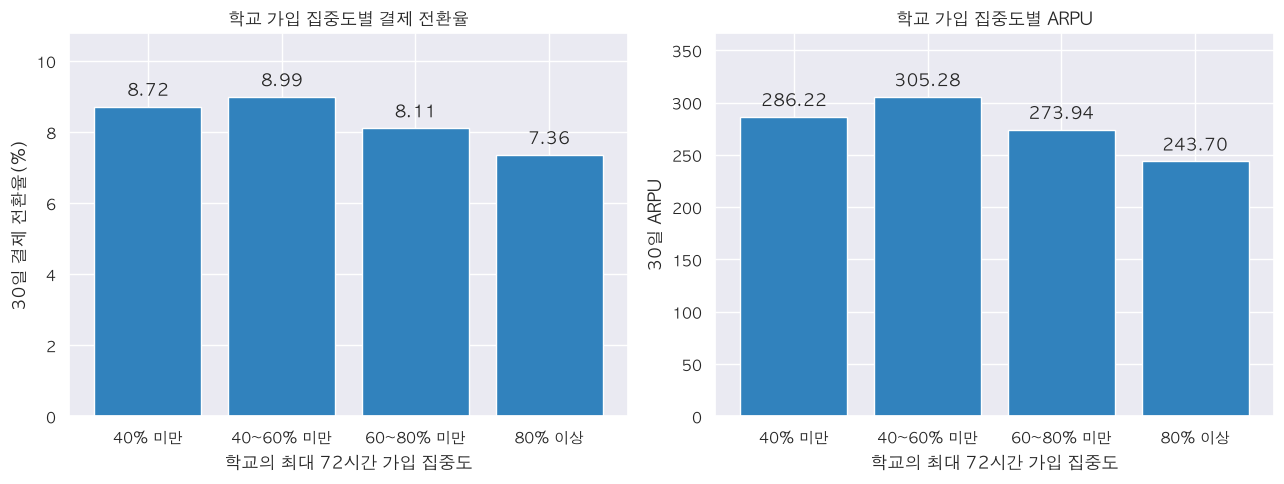

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in [
    (axes[0], '30일 결제 전환율(%)', '학교 가입 집중도별 결제 전환율'),
    (axes[1], '30일 ARPU', '학교 가입 집중도별 ARPU'),
]:
    values = concentration_payment_summary[metric]

    bars = ax.bar(
        concentration_payment_summary['집중도 구간'].astype(str),
        values,
        color='#3182bd',
    )

    ax.bar_label(
        bars,
        labels=[
            f'{value:,.2f}' if pd.notna(value) else ''
            for value in values
        ],
        padding=4,
    )

    ax.set_title(title)
    ax.set_xlabel('학교의 최대 72시간 가입 집중도')
    ax.set_ylabel(metric)
    ax.margins(y=0.2)

fig.tight_layout()
plt.show()

# 학교급 나눠서 추가

In [48]:
school_types = (
    df[['school_id', 'school_type']]
    .dropna(subset=['school_id'])
    .drop_duplicates()
)

if school_types['school_id'].duplicated().any():
    raise ValueError('같은 학교에 여러 school_type이 연결되어 있습니다.')

school_payment_by_type = school_payment_comparison.merge(
    school_types,
    on='school_id',
    how='left',
    validate='one_to_one',
)

school_payment_by_type['학교급'] = (
    school_payment_by_type['school_type']
    .map({'M': '중학교', 'H': '고등학교'})
    .fillna('미상')
)

In [49]:
type_concentration_summary = (
    school_payment_by_type
    .groupby(['학교급', '집중도 구간'], observed=True)
    .agg(
        학교수=('school_id', 'nunique'),
        관찰가능가입자수=('관찰가능가입자수', 'sum'),
        결제자수_30일=('결제자수_30일', 'sum'),
        결제금액_30일=('결제금액_30일', 'sum'),
    )
    .reset_index()
)

# 앞서 정의한 함수 재사용
type_concentration_summary = add_payment_metrics(
    type_concentration_summary
)

for school_type in ['중학교', '고등학교', '미상']:
    result = type_concentration_summary.loc[
        type_concentration_summary['학교급'].eq(school_type)
    ]

    if not result.empty:
        print(school_type)
        display(result.round(2))

중학교


,학교급,집중도 구간,학교수,관찰가능가입자수,결제자수_30일,결제금액_30일,30일 결제 전환율(%),30일 ARPU,30일 ARPPU
4,중학교,40% 미만,225,24132,1851,6081600,7.67,252.01,3285.58
5,중학교,40~60% 미만,676,97176,7047,23624100,7.25,243.11,3352.36
6,중학교,60~80% 미만,728,128022,8253,27063000,6.45,211.39,3279.17
7,중학교,80% 이상,226,35599,2041,6077000,5.73,170.71,2977.46


고등학교


,학교급,집중도 구간,학교수,관찰가능가입자수,결제자수_30일,결제금액_30일,30일 결제 전환율(%),30일 ARPU,30일 ARPPU
0,고등학교,40% 미만,408,59435,5433,17837200,9.14,300.11,3283.12
1,고등학교,40~60% 미만,811,138639,14149,48366300,10.21,348.87,3418.35
2,고등학교,60~80% 미만,695,144467,13846,47582700,9.58,329.37,3436.57
3,고등학교,80% 이상,127,27768,2622,9365700,9.44,337.28,3571.97


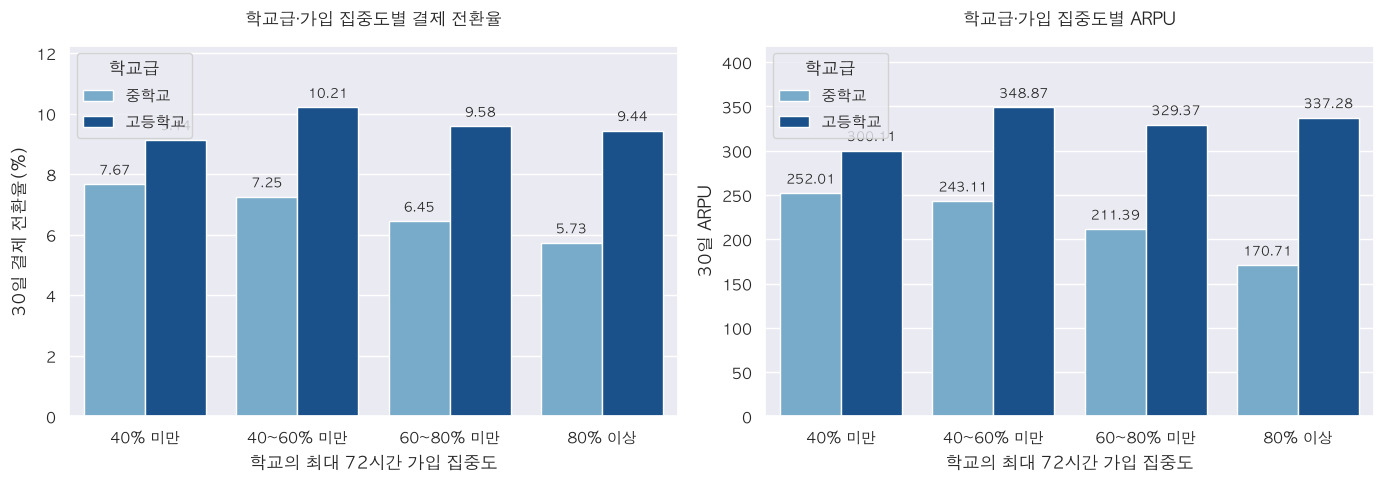

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

concentration_order = [
    '40% 미만',
    '40~60% 미만',
    '60~80% 미만',
    '80% 이상',
]

plot_data = type_concentration_summary.loc[
    type_concentration_summary['학교급'].isin(['중학교', '고등학교'])
]

for ax, metric, title in [
    (axes[0], '30일 결제 전환율(%)', '학교급·가입 집중도별 결제 전환율'),
    (axes[1], '30일 ARPU', '학교급·가입 집중도별 ARPU'),
]:
    sns.barplot(
        data=plot_data,
        x='집중도 구간',
        y=metric,
        hue='학교급',
        order=concentration_order,
        hue_order=['중학교', '고등학교'],
        palette=['#6baed6', '#08519c'],
        errorbar=None,
        ax=ax,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f'{value:,.2f}' if pd.notna(value) else ''
                for value in container.datavalues
            ],
            padding=4,
            fontsize=9,
        )

    ax.set_title(title, pad=15)
    ax.set_xlabel('학교의 최대 72시간 가입 집중도')
    ax.set_ylabel(metric)
    ax.legend(title='학교급')
    ax.margins(y=0.2)

fig.tight_layout()
plt.show()

학교급별로 구분한 결과, 중학교에서는 가입 집중도가 높을수록 30일 결제 전환율과 ARPU가 낮아지는 관계가 관찰되었다. 반면 고등학교는 40~60% 구간에서 가장 높은 성과를 보였으나, 높은 집중도 구간에서도 상대적으로 높은 결제 성과를 유지했다. 따라서 가입 집중도와 결제 성과의 관계는 학교급에 따라 다르게 나타나며, 전체 학교를 합산한 결과만으로 해석하기 어렵다.